# FAST-based feature filtering demo

This notebook demonstrates internal FAST-based feature filtering for factual explanations.

The core idea:
- Run an internal FAST pass on the same batch to obtain per-instance feature weights.
- Aggregate those weights and keep only the top-k most important features for the batch.
- Run the full factual explanation on this reduced feature set, reducing compute cost.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)


from calibrated_explanations import WrapCalibratedExplainer, __version__
from calibrated_explanations.api.config import ExplainerBuilder

print(f"Using calibrated_explanations version: {__version__}")

Using calibrated_explanations version: 0.11.3


In [3]:
# Generate a simple classification dataset with many features
X, y = make_classification(
    n_samples=2000,
    n_features=2000,
    n_informative=5,
    n_redundant=5,
    random_state=42,
)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=50, random_state=42)
X_train_proper, x_cal, y_train_proper, y_cal = train_test_split(
    x_train, y_train, test_size=200, random_state=42
)

learner = RandomForestClassifier(n_estimators=50, random_state=42)
learner.fit(X_train_proper, y_train_proper)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [4]:
# Build an ExplainerConfig with internal feature filtering enabled
builder = ExplainerBuilder(learner)
config = (
    builder
    .perf_parallel(False)  # Disabled parallelism
    .perf_feature_filter(True, per_instance_top_k=5)
    .build_config()
)

# Construct the wrapper from the config
wrapper = WrapCalibratedExplainer.from_config(config)

# Calibrate the explainer (perf cache/parallel + feature filter are wired internally)
wrapper.calibrate(x_cal, y_cal)
explainer = wrapper.explainer
explainer

CalibratedExplainer(mode=classification, learner=RandomForestClassifier(n_estimators=50, random_state=42))

In [5]:
# Run factual explanations with internal FAST-based feature filtering enabled
explanations = wrapper.explain_factual(x_test)

C:\Users\loftuw\Documents\Github\moffran\calibrated_explanations\src\calibrated_explanations\core\explain\orchestrator.py:1167: UserWarning: Auto-selecting experimental 'fast' explanation mode for feature filtering. The 'fast' pathway is experimental and opt-in only. Set CE_FEATURE_FILTER=off or disable feature_filter_config to suppress.
  return self.invoke(


In [6]:
explanations[:5].to_narrative()

,instance_index,factual_explanation_beginner,factual_explanation_advanced,expertise_level,problem_type
0,0,Prediction: 1\nCalibrated Probability: 0.545\n...,Prediction: 1\nCalibrated Probability: 0.545\n...,"(beginner, advanced)",binary_classification
1,1,Prediction: 1\nCalibrated Probability: 0.714\n...,Prediction: 1\nCalibrated Probability: 0.714\n...,"(beginner, advanced)",binary_classification
2,2,⚠️ Use caution: uncertainty is high.\n\nPredic...,⚠️ Use caution: calibrated probability interva...,"(beginner, advanced)",binary_classification
3,3,Prediction: 1\nCalibrated Probability: 0.300\n...,Prediction: 1\nCalibrated Probability: 0.300\n...,"(beginner, advanced)",binary_classification
4,4,Prediction: 1\nCalibrated Probability: 0.545\n...,Prediction: 1\nCalibrated Probability: 0.545\n...,"(beginner, advanced)",binary_classification


Prediction [ Low ,  High]
0.545 [0.526, 0.568]
Value : Feature                                  Weight [ Low  ,  High ]
-1.21 : 7 > -2.91                                 0.545 [ 0.545,  0.545]
-0.23 : 459 <= 0.29                              -0.012 [-0.034,  0.005]
-0.39 : 355 <= -0.24                             -0.004 [-0.026,  0.014]



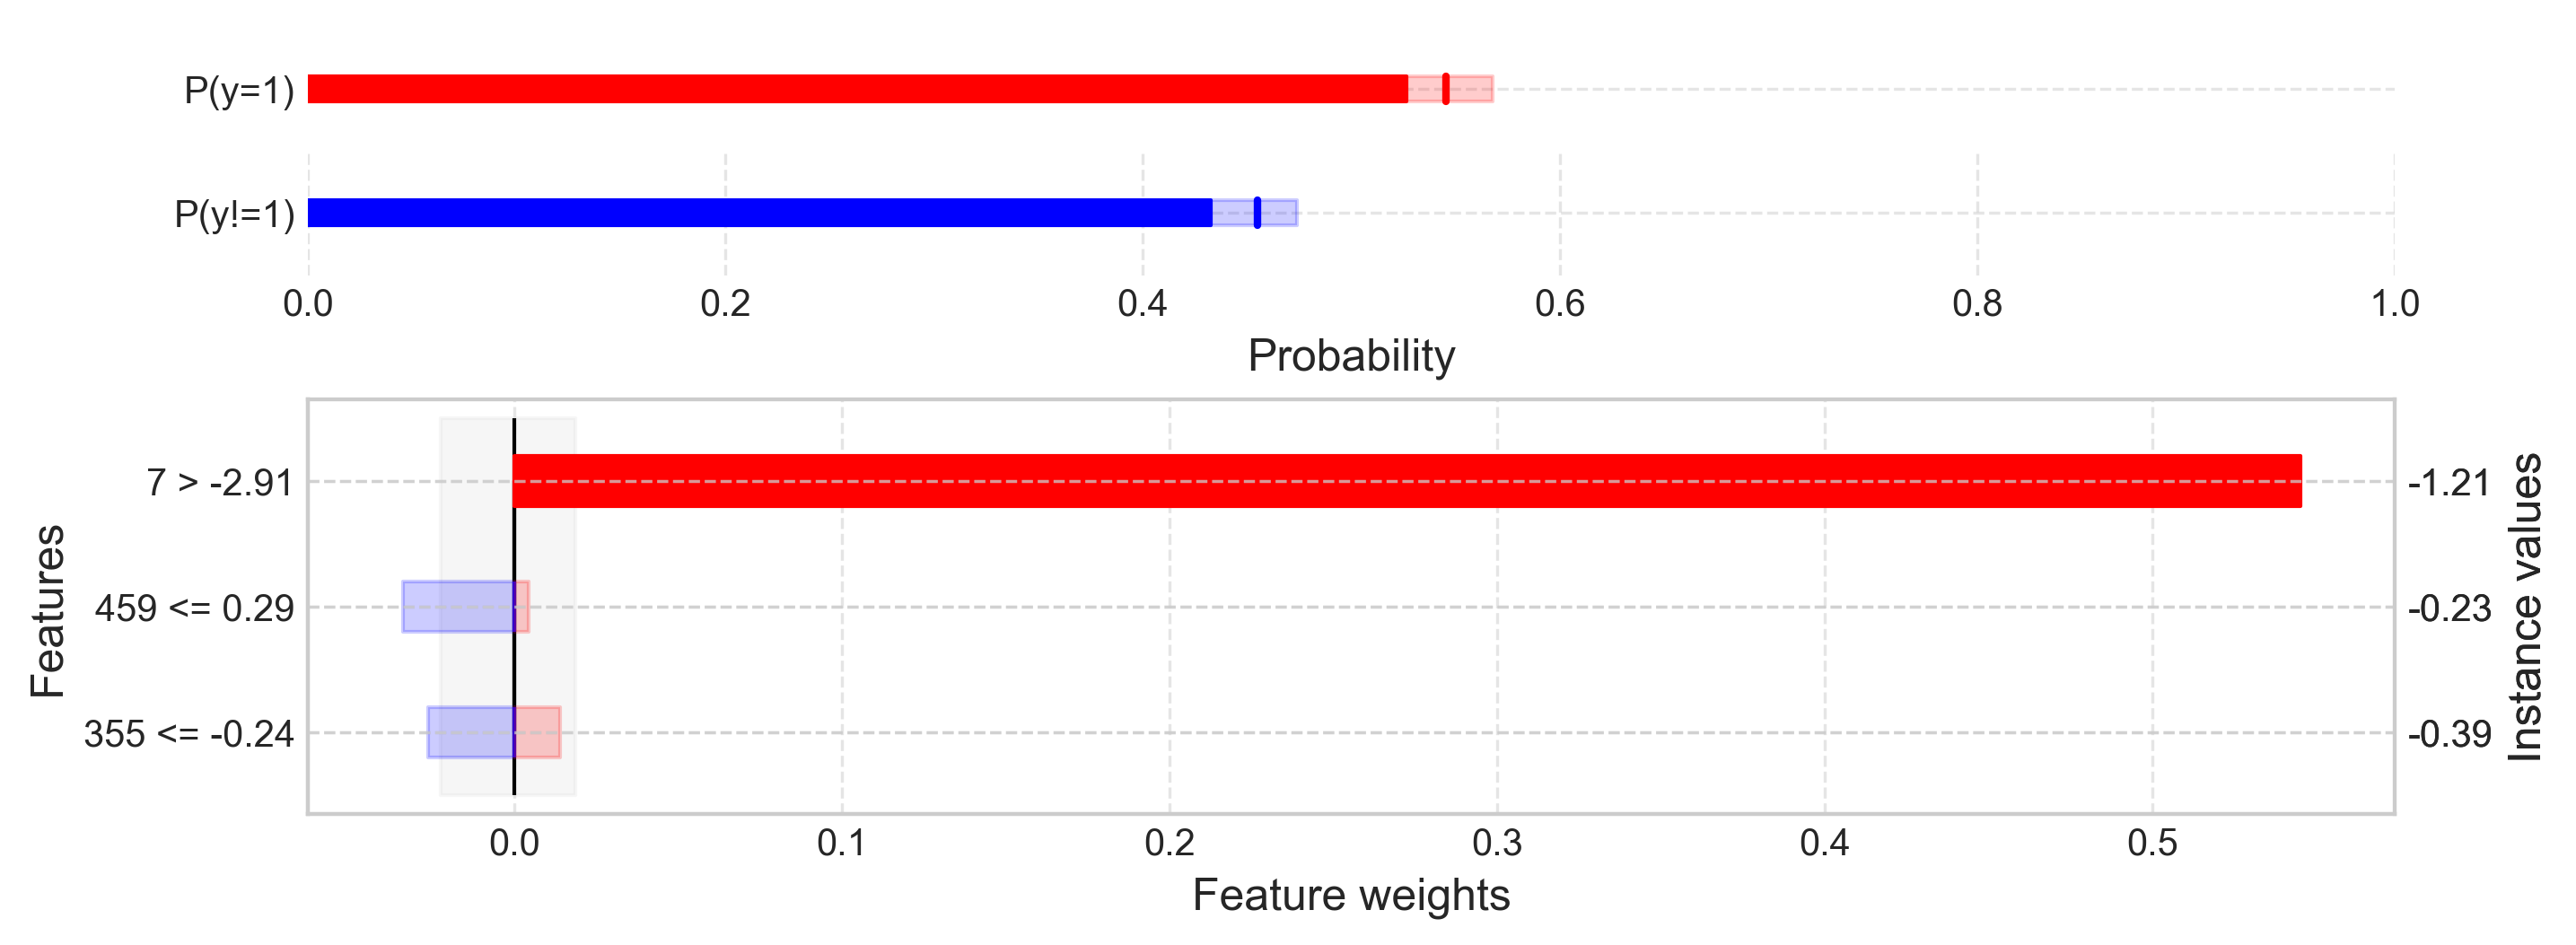

Prediction [ Low ,  High]
0.714 [0.700, 0.750]
Value : Feature                                  Weight [ Low  ,  High ]
0.09  : 1874 > -1.29                              0.714 [ 0.714,  0.714]



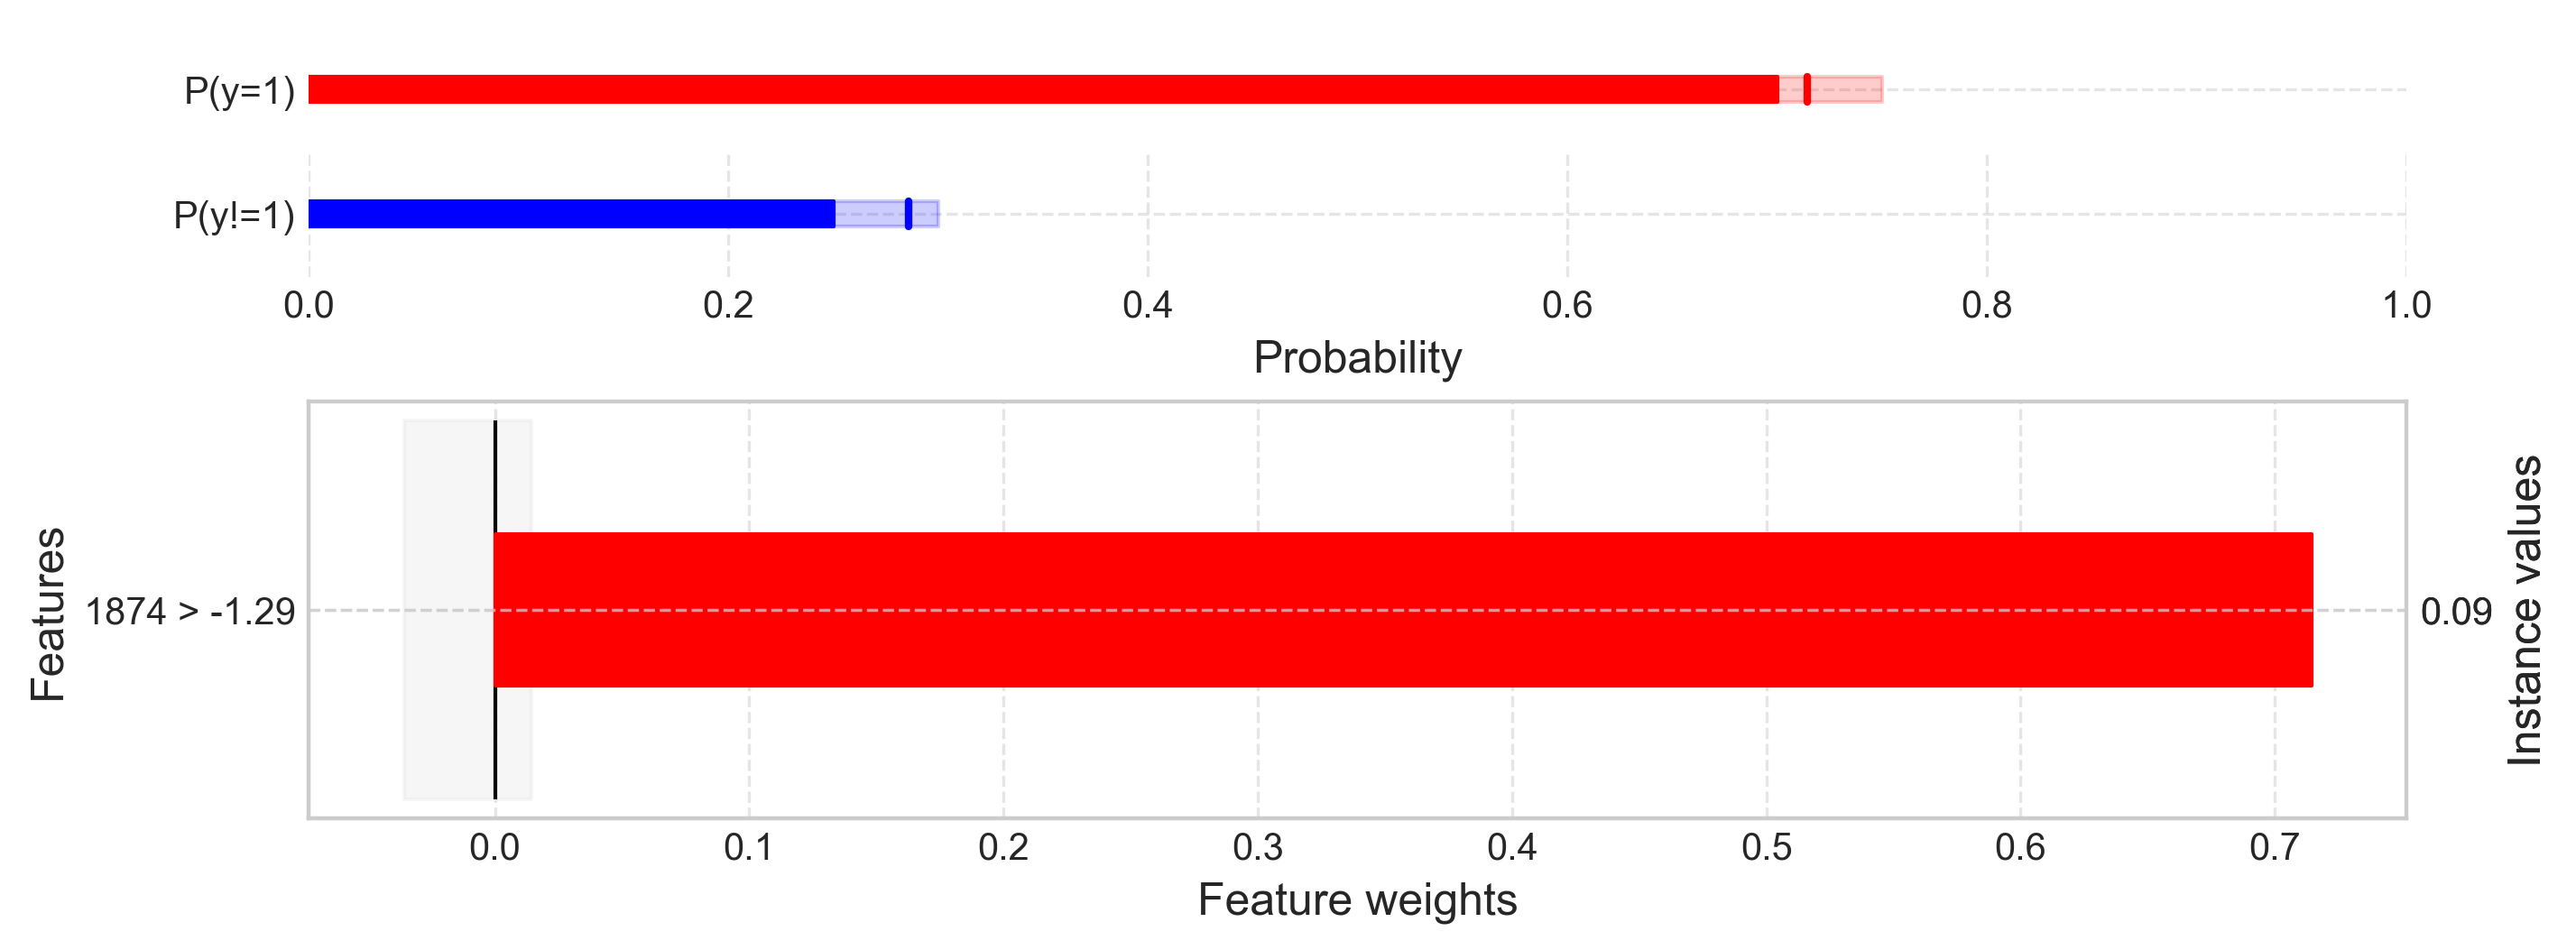

Prediction [ Low ,  High]
0.824 [0.786, 1.000]
Value : Feature                                  Weight [ Low  ,  High ]
1.93  : 1082 > -2.13                              0.824 [ 0.824,  0.824]
1.88  : 1359 > 1.10                              -0.065 [-0.176, -0.051]
-0.91 : 1360 > -3.25                             -0.000 [-0.176,  0.038]
3.4   : 153 > 1.62                               -0.000 [-0.176,  0.038]
0.34  : 1744 <= 2.15                             -0.000 [-0.176,  0.038]



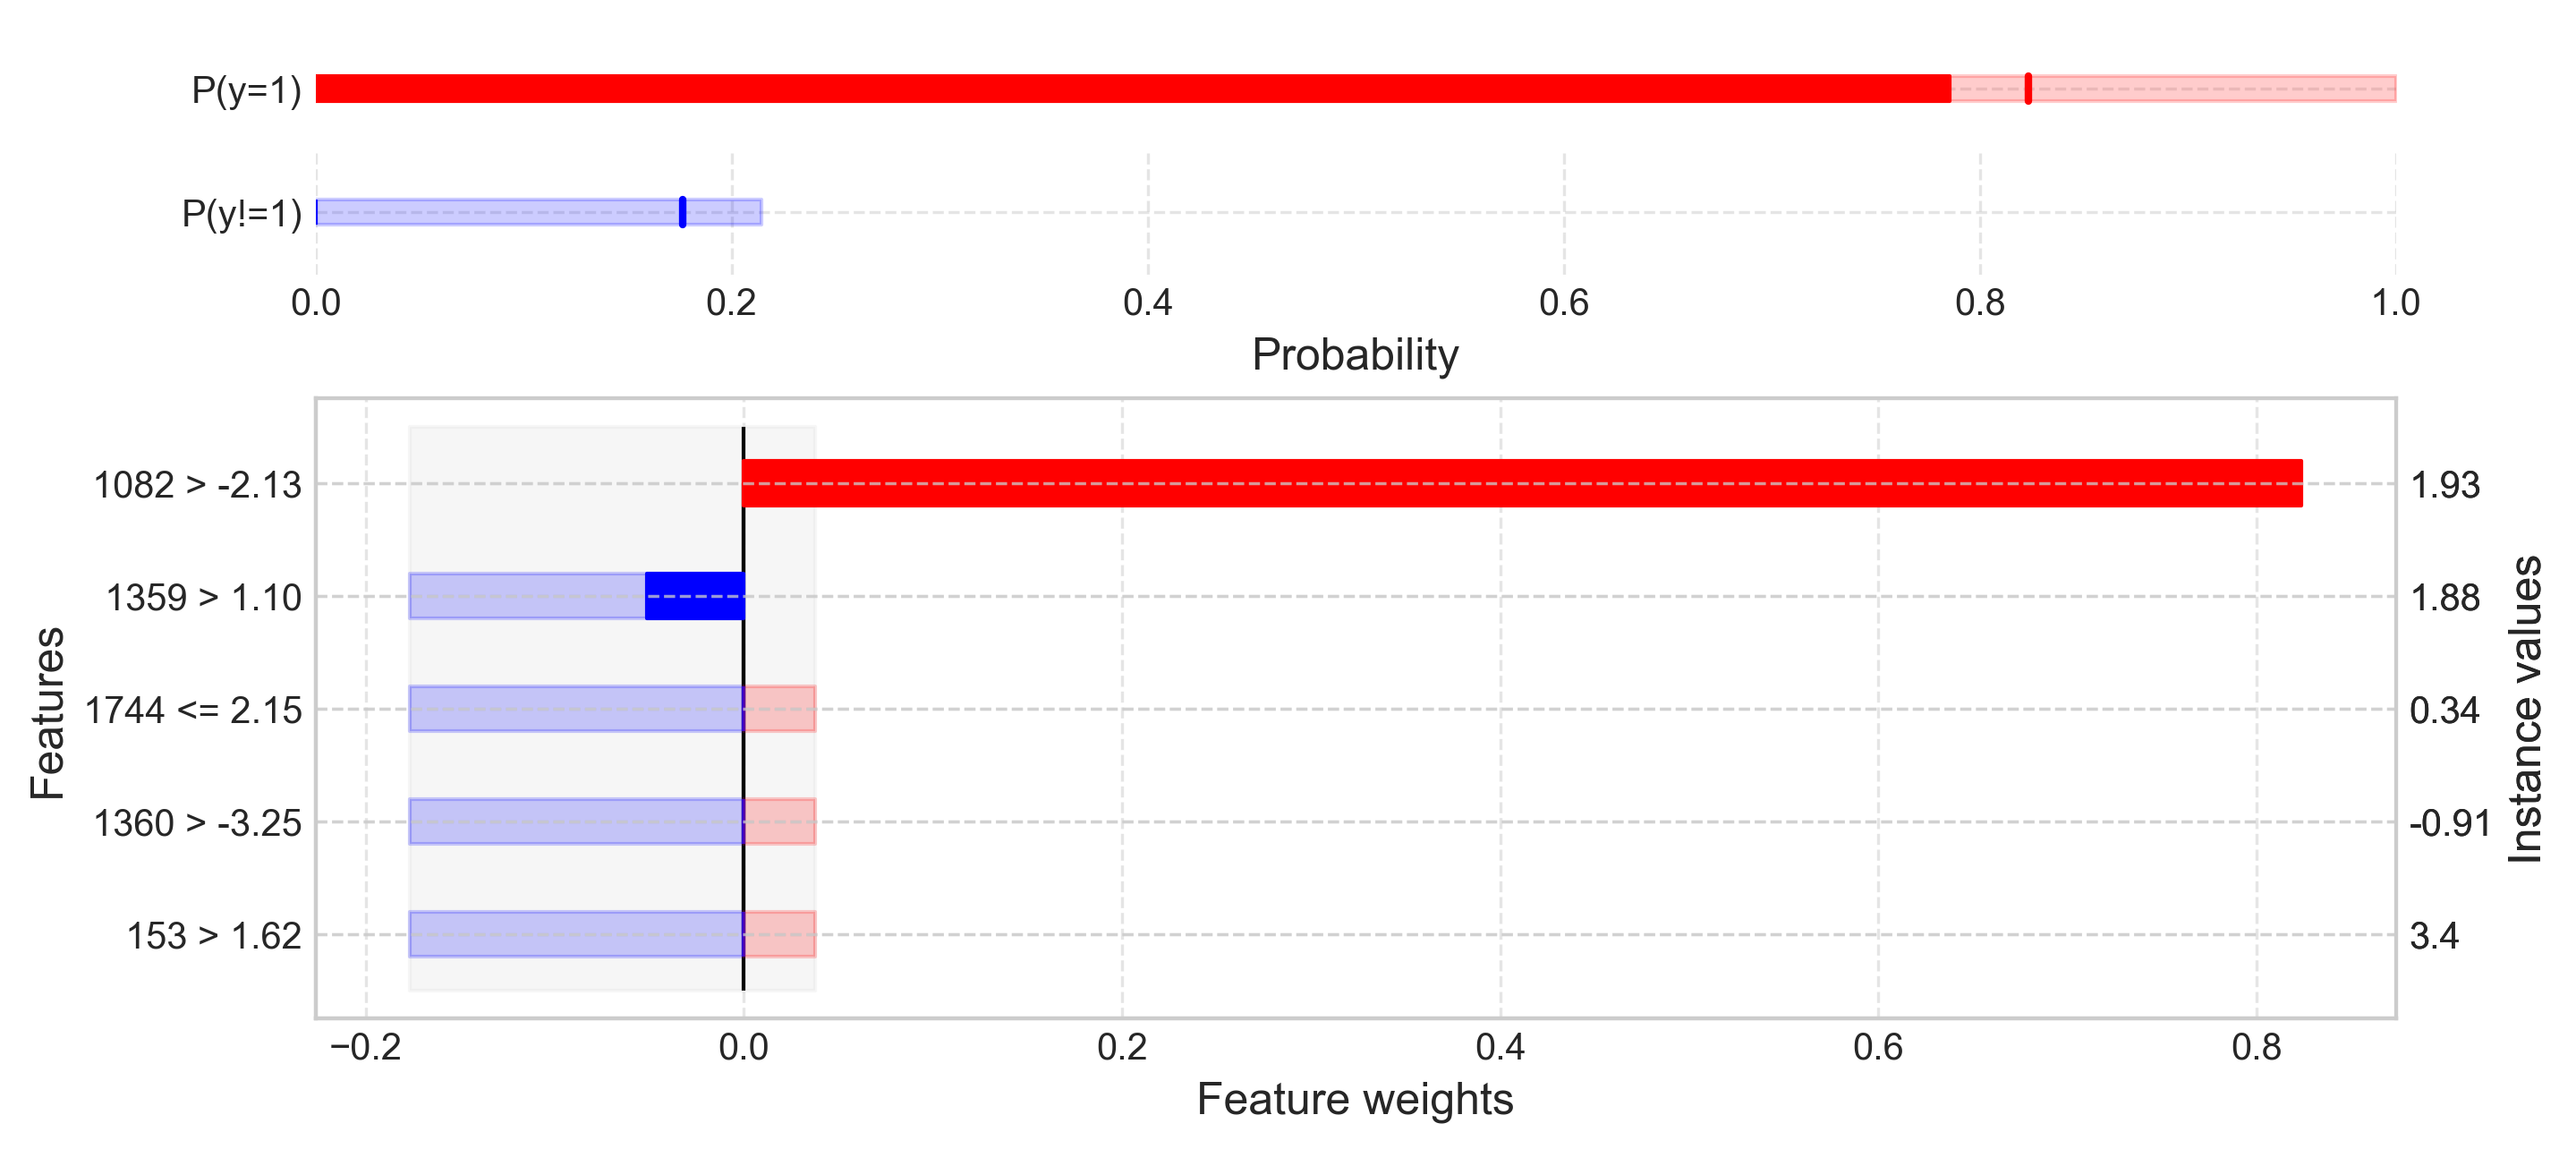

Prediction [ Low ,  High]
0.300 [0.263, 0.316]
Value : Feature                                  Weight [ Low  ,  High ]
-0.86 : 329 <= -0.79                              0.050 [ 0.041,  0.078]



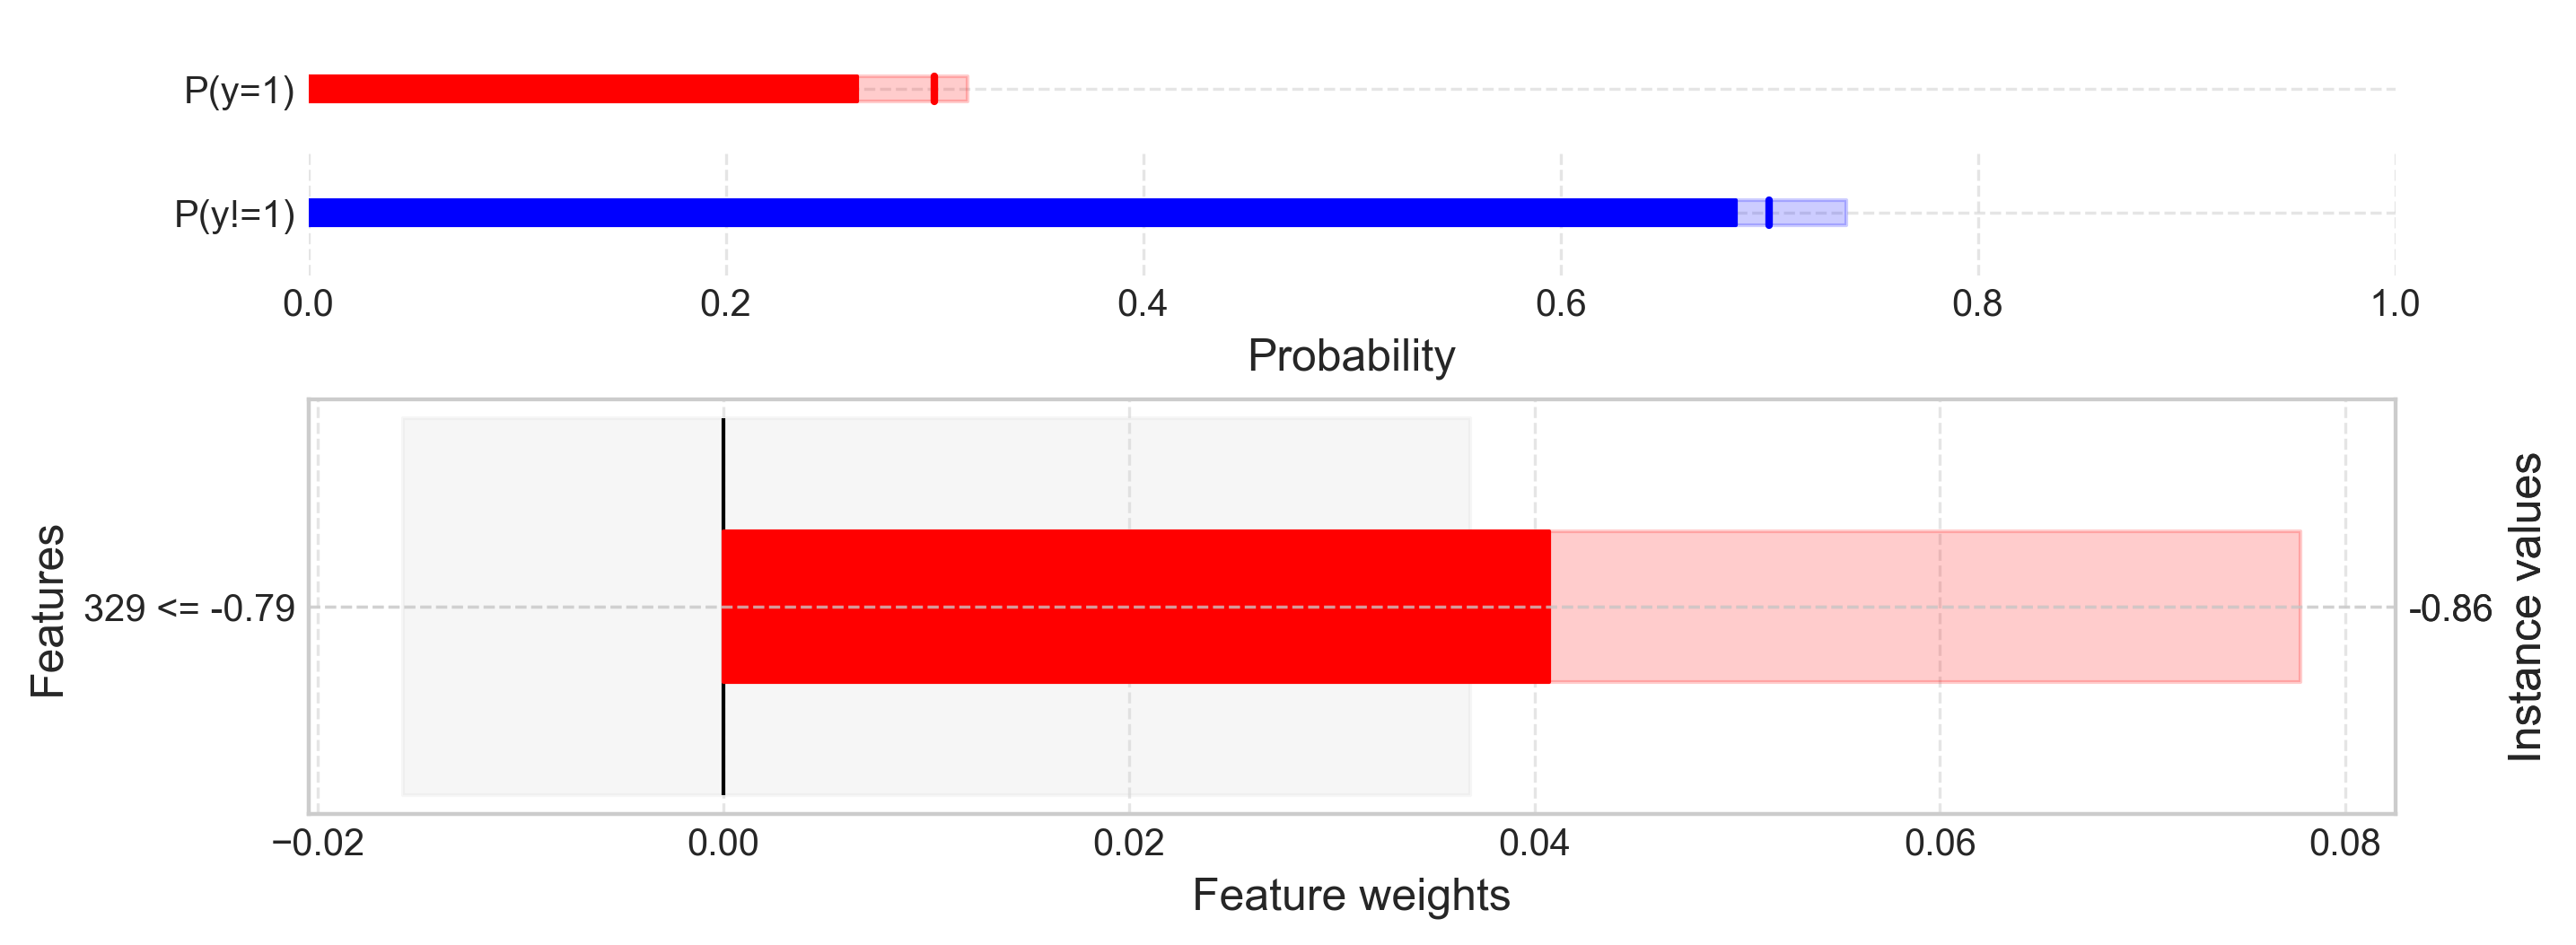

Prediction [ Low ,  High]
0.545 [0.526, 0.568]
Value : Feature                                  Weight [ Low  ,  High ]
3.02  : 7 > -2.91                                 0.545 [ 0.545,  0.545]
0.38  : 247 <= 0.77                               0.245 [ 0.229,  0.282]
1.21  : 329 > -0.79                              -0.057 [-0.092, -0.035]



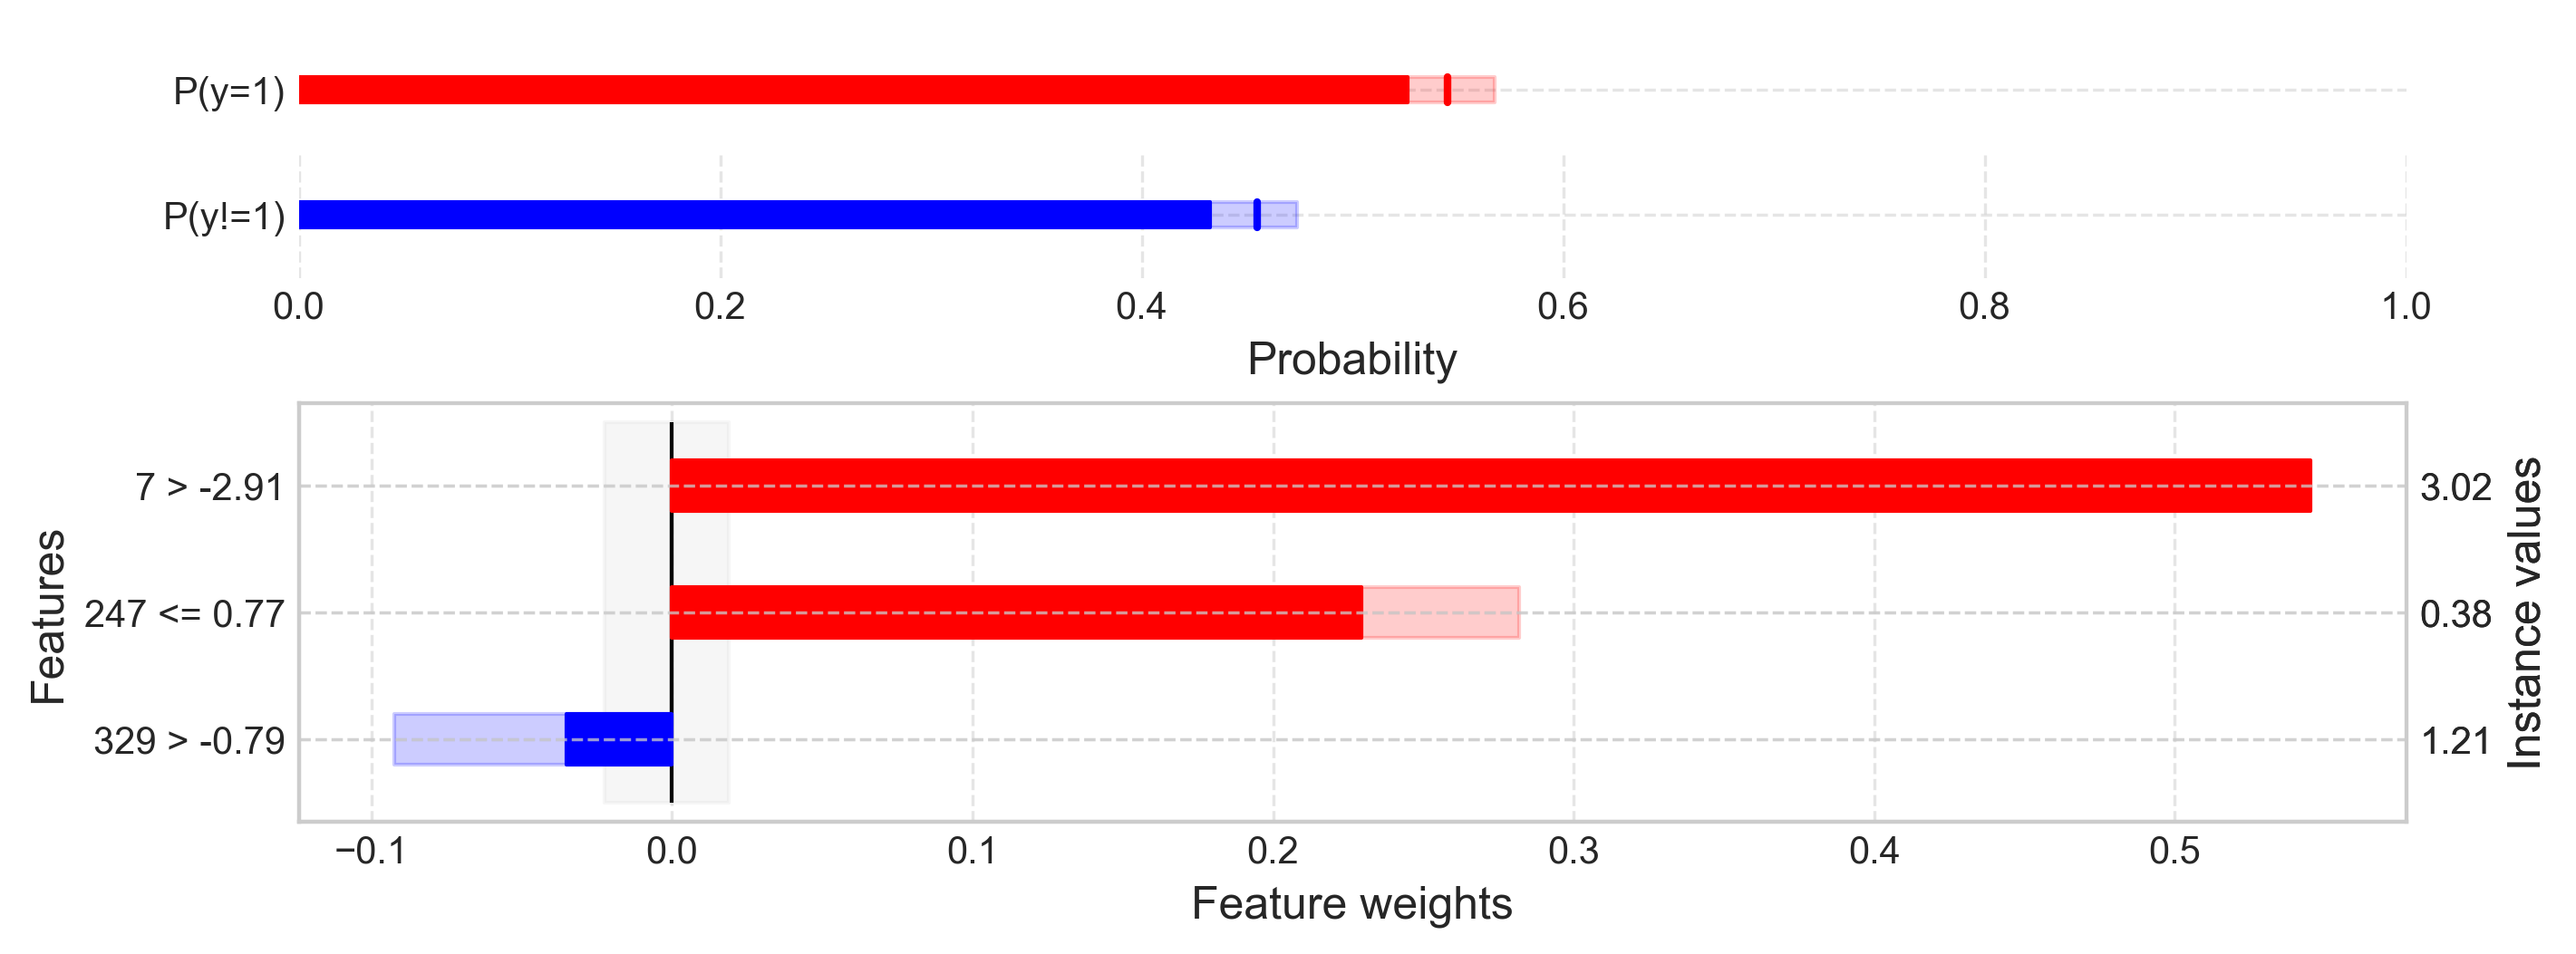

In [7]:
for e in explanations[:5]:
    print(e)
    e.plot(uncertainty=True)

In [8]:
# Inspect how many features remain after filtering
num_features = explainer.num_features
ignored = set(explanations.features_to_ignore)
kept = [f for f in range(num_features) if f not in ignored]
num_features, len(kept), kept

(2000,
 64,
 [7,
  11,
  153,
  196,
  247,
  324,
  329,
  338,
  355,
  393,
  459,
  519,
  529,
  635,
  639,
  673,
  719,
  725,
  752,
  819,
  845,
  851,
  872,
  894,
  907,
  936,
  967,
  993,
  999,
  1041,
  1082,
  1086,
  1149,
  1166,
  1177,
  1226,
  1231,
  1253,
  1262,
  1267,
  1269,
  1357,
  1359,
  1360,
  1437,
  1443,
  1504,
  1558,
  1635,
  1679,
  1698,
  1702,
  1744,
  1812,
  1833,
  1834,
  1839,
  1874,
  1911,
  1926,
  1937,
  1958,
  1961,
  1973])

The length of `kept` should be less than or equal to `per_instance_top_k` passed to `perf_feature_filter`.

You can tweak `per_instance_top_k` and rerun the notebook to see how the effective feature budget changes.

In [9]:
# Construct the wrapper from the config
wrapper_all = WrapCalibratedExplainer(learner)

# Calibrate the explainer (perf cache/parallel + feature filter are wired internally)
wrapper_all.calibrate(x_cal, y_cal)
explainer = wrapper_all.explainer

In [10]:
explanations_all = wrapper_all.explain_factual(x_test)
explanations_all.features_to_ignore

array([], dtype=int64)